Unpublished

This is an unpublished article, unfortunately.

## Extracting Topology

We can extract topology into what matters:

* Call graph
* File structure
* Import graph
* Inheritance graph / polymorphism graphs
* Type reference graph (could be just treated as normal code composition)
* Dependency graph

## Indexing the Topology

In this article, to index topology, I use LMDB. It's a weird choice, but there are reasons why I think it's the best choice here:

1. It embeds into the codebase itself
2. Very performant, especially for queries
3. Memory mapped backing means OS can eagerly cache in memory
4. It's a raw K-V store built on top of a B+-tree. This means our keys stay sorted and we can do point lookups then range scans.

### Schema

Since we're working with just a K-V store, we need to tightly define the schema as specific primary indices.

```

```

## But wait, there's more

Code also tends to have side channels apart from the graph search which we can take advantage of:

* symbol usage frequency
* git churn
* dependency centrality
* test coverage
* runtime traces
* ownership
* recency

## The Hypothesis

**LLMs don't need inifinite context in codebases. They need the *correct* context**.

We can rely on the graph behavior and natural organization of code to efficiently and cheaply provide large context access to LLMs. By doing this, we can allow smaller models to operate at levels similar to larger models without a significant drop in accuracy.

## Why I Believe this?

Currently, the industry is moving towards cramming entire codebases into model context. That doesn't scale. But most importantly, this significantly differs from how humans code. We don't memorize our entire codebases... instead, we search through codebases and build just enough context to solve our current problem.

## Adapting Search

Let's attempt to adapt search to better fit agentic coding.

### PageRank

**PageRank** was a breakthrough in web-scale search. The idea behind PageRank was to rank which articles were important by treating every time that link was seen similar to an academic reference.

PageRank used how often an article was backlinked to not just see if a page contained a keyword, but whether that page is *important, relevant and trusted*.

> **PageRank algorithm**
> $$\text{PR}(A) = \frac{1-d}N + d\sum_{i=1}^n{\frac{\text{PR}(T_i)}{C(T_i)}}$$
> 
> Where
> 
> $\text{PR}(x)$ is the page rank of $x$
> 
> $T_i$ represents the pages linking to page $A$
> 
> $C(T_i)$ represents the total number of outbound links on page $T_i$

### What to Extract from Code

Let's start by cataloging all of the data we can efficiently compute and have at our disposal:

* Code graph
    * Import graph
    * Call graph
    * Inheritance graph / polymorphism graphs
    * Type reference graph (could be just treated as normal code composition)
    * Dependency graph
* Side channels
    * symbol usage frequency: probably a foundational building block in the codebase
    * git churn: high churn mean active development or code functional code which matters
    * dependency centrality: a bloom filter for foundational building blocks
    * test coverage: critical components tend to have better test coverage

Next, we can develop indexing and retrieval algorithms to use these features.

### Feature Extraction

Unlike arbitrary text for search, as if we were building Google, code follows syntax and is intentionally machine readable. Let's take advantage of that.

1. Step 1: determine language
2. Step 2: call a language extractor which works with that language. Prototype:
    * Doxygen for C/C++/most popular languages
    * TypeScript compiler + tsdoc/jsdoc for js-based languages
    * something for openapi and grpc (not sure what, maybe custom, or find something)
    * These two should cover like 90% of code
3. Step 3: extract everything and index.

### Index Format

Note: these need recursive engineering to turn into a well-oiled schema.

```
sf:fully.qualified.code.name -> record for the code // allows for namespace-based autocomplete
sb:name.code.qualified.fully -> record for the code // allows to search from the actual name of the piece of code
rc:record_id -> { code details }    // stores the info for that piece of code so we don't store it twice and feel pain in index update
lr:{rootid}:{filepath}:{lineno} -> record for the code

rt:root-id -> { configuration about the root }
```

```ts
type FQN = string;
type RootId = string; // int would be better and faster

interface code_details {
    fqn: FQN; // fully qualified name

    ref_in: FQN[] | null; // array of fqn of references in
    ref_in_ct: number; // # fqn references in (needed so we can drop the array of references in code referenced *everywhere*)
    ref_out: FQN[]; // fqn array of references out
    
    root_id: RootId; // where this exists (which project / repo / etc. this matters since you need to onboard different dirs of code into the index)
    file: string;
    lineno: number;
}

interface RootConfig {
    id: RootId;
    disk_path: string;
    remote_paths: string[];
}
```

Additionally, to keep this as a simple prototype, instead of building an inverted index for text, we'll index comments and other text in Sqlite3/fts5.

```sql
PRAGMA journal_mode = WAL;
PRAGMA synchronous = NORMAL;
PRAGMA temp_store = MEMORY;

CREATE VIRTUAL TABLE text_search USING fts5(
    root_id UNINDEXED,
    file UNINDEXED,
    lineno UNINDEXED,
    text,
    tokenize = 'unicode61 remove_diacritics 2'
);
```

### Searching

Do a text search in `sf:{query}` and `sb:{query}` to query LMDB. This is actually generally fine because we're working with code, and names in code are EXACT.

> **Potential improvement:**
>
> store `sf:...` and `sb...` as `sfn:{normalized sf}` and `sbn:{normalized sb}`:
> * fully lowercase
> * normalize to remove all non-ascii chars

Simultaneously, query the FTS5 table.

### Ranking

Without ranking, we have not built code retrieval. We have built Confluence search, but for code. No one wants that!

Prioritization comes from using heuristics to try to decide what is important and most likely to be what you're looking for. Our goal is to collect as much data from the code as well as *side channel* data to highlight the importance of a result.

Potential ranking algorithm:

```js
function rank(
    searchMatchPct: number, // percentage the search matched
    numLinksIn: number,
    referencesIn: FQN[],
    referencesOut: FQN[],
    maxDepth: number = 6,
) {
    if (maxDepth <= 0) return 0;
    
    return searchMatchPct * 3 +
        numLinksIn * 2 +
        referencesOut.length +
        (Math.sum(
            referencesIn
                ?.map(refIn => resolve(refIn))
                ?.map(res => rank(0, res.ref_in_ct, res.ref_in, res.ref_out, maxDepth - 1)) ?? numLinksIn
        ));
}
```

Note that teh algo above is just an example. Things to be added:
* Decay
* Penalties

### Immediate cascading delete

Note that an alternative could be use a memtable-type blob which can tell the LLM or search algo what changed recently. We won't do it here since seems like reindexing isn't particularly hard.

When code is updated, we need to immediately update the index otherwise our search results will be out of date. This is a hard-ish requirement for LLM usage.

Immediately when a file is changed:

1. Delete all records in Sqlite3/fts5 `WHERE root_id = root_id AND file = filepath`
2. Query LMDB for all records `lr:{rootid}:{filepath}:` and capture a list of all pointers
3. Delete all LMDB records for `lr:{rootid}:{filepath}:*`
4. Visit `rc:{record_id}` for each deleted record, delete that record keeping the FQN
5. Delete `sf:{fqn}` for each FQN we captured
6. Delete `sb:{reversed fqn}` for each FQN we captured
7. Index the file again

## Implementation Notes

* Prototype
* LMDB and FTS5 for DB/search only
* daemon process
    * Indexing
    * File watching
* CLI
    * queries the daemon
    * adds / deletes directories as roots to the daemon
    * communicates with the daemon somehow (maybe unix sockets or smtn like that?)

## How the Implementation Differs from the Original Thesis (written by Codex, edited by me)

The implementation follows the core thesis, but it has already diverged from the first sketch in a few important ways.

First, the implementation is more modular than the original notes. Instead of treating indexing as one big process, Hypercode now has a pipeline:

1. Crawlers find documents.
2. Extractors turn documents into an intermediate representation.
3. Annotators can enrich that IR later.
4. Indexers write the IR into LMDB and SQLite FTS5.
5. The daemon coordinates the whole thing and exposes it to the CLI.

This split matters because code search will not stay limited to code forever. Markdown, notebooks, images, PDFs, generated artifacts, and traces all need somewhere to fit without turning the indexer into a pile of special cases.

Second, records are no longer identified by hashes or by FQN alone. Each record gets a monotonic microsecond timestamp `record_id`. This means records are unique even when two files describe the same logical symbol, and LMDB record scans naturally behave like a recency list.

This became important for C and C++. A header can contain a declaration while a source file contains the implementation. Those should not overwrite each other. The implementation treats them as separate records connected by a duplicate group. Search can prefer the implementation, but still expose the declaration because agents often need both.

Third, the implementation separates record identity from symbol identity:

* `record_id` answers: which concrete indexed occurrence is this?
* `fqn` answers: what logical symbol or document section does this represent?
* `duplicate_group_key` answers: which records appear to represent the same logical thing?

The original thesis implied a simpler one-to-one mapping from FQN to record. That is too small for real code.

Fourth, normalized indexes became first-class. The original thesis listed `sfn` and `sbn` as a potential improvement. The implementation includes them:

* `sf:{fqn}:{record_id}`
* `sb:{reversed_fqn}:{record_id}`
* `sfn:{normalized_fqn}:{record_id}`
* `sbn:{normalized_reversed_fqn}:{record_id}`

These are one-to-many indexes now, because duplicates and overloads are expected.

Fifth, FTS5 indexes more than comments. The original notes focused on comments and text. The implementation indexes:

* comments
* docs
* string literals
* markdown
* notebook markdown cells

That reflects a practical realization: for coding agents, important context often lives in docs, README files, notebook notes, error strings, SQL strings, route strings, config-ish strings, and other text side channels.

Finally, the current implementation includes debug tools much earlier than the thesis suggested. This is not part of the retrieval idea itself, but it is necessary for developing the system. If search quality is the product, then being able to inspect LMDB keys, FTS5 rows, raw records, file records, and index stats is not optional. It is how we learn whether the retrieval machinery is telling the truth.

So the thesis remains the same:

**LLMs do not need infinite context in codebases. They need the correct context.**

But the implementation has made the shape of "correct context" more concrete. It is not just symbols and text. It is records, occurrences, duplicate groups, document structure, source spans, graph links, side-channel text, and enough debug visibility to make the system measurable.


\[Thursday, May 21, 2026]

## What worked and didn't? (by me)

### What Worked

Text search (Sqlite3/FTS5) worked fine. I indexed this website's codebase (which is actually surprisingly complex) and was able to search "yash101". The search results included the jupyter notebooks I compose the content in!

### What didn't work

* Symbol tracing didn't work.
* Indexing was atrociously slow
* Symbol FQNs need to be standardized across languages. It's fine if they lose a bit of data
    * Perhaps sfn/sbn indices can have the standardized versions and sf/sb have the raw versions
    * Perhaps we need an alias table to connect known equivalent symbols together. This specifically would bring in support for mangling/demangling and across architectures

Why?

* The LMDB indices were not powerful enough
* Indexing / document extraction was very unoptimized and slow
* Search APIs need significant improvement / should be split up into multiple tools for LLMs.
* LMDB is CoW. Since I was writing one record at a time, LMDB was thrashing. This requires a bit of an architectural change.

Other small things

* ChatGPT codex decided to invent its own RPC codec (JSON over UDS). I fixed this early on by asking Codex to just use HTTP over UDS instead.

## Re-implementation (by me)

Codex' prototype worked OK, but wasn't groundbreaking. I realized there's a lot of room for improvement.

1. The index for my website was only ~5 MB. That's tiny and gives us a lot of room for deeper analysis
2. Capturing graph changes is really hard with cascading deletes
    * Updating references in is surprisingly hard because it kind of requires a whole db walk. That doesn't work.
  
Feeling a bit stuck, I decided to go oldschool and whiteboard the problem.

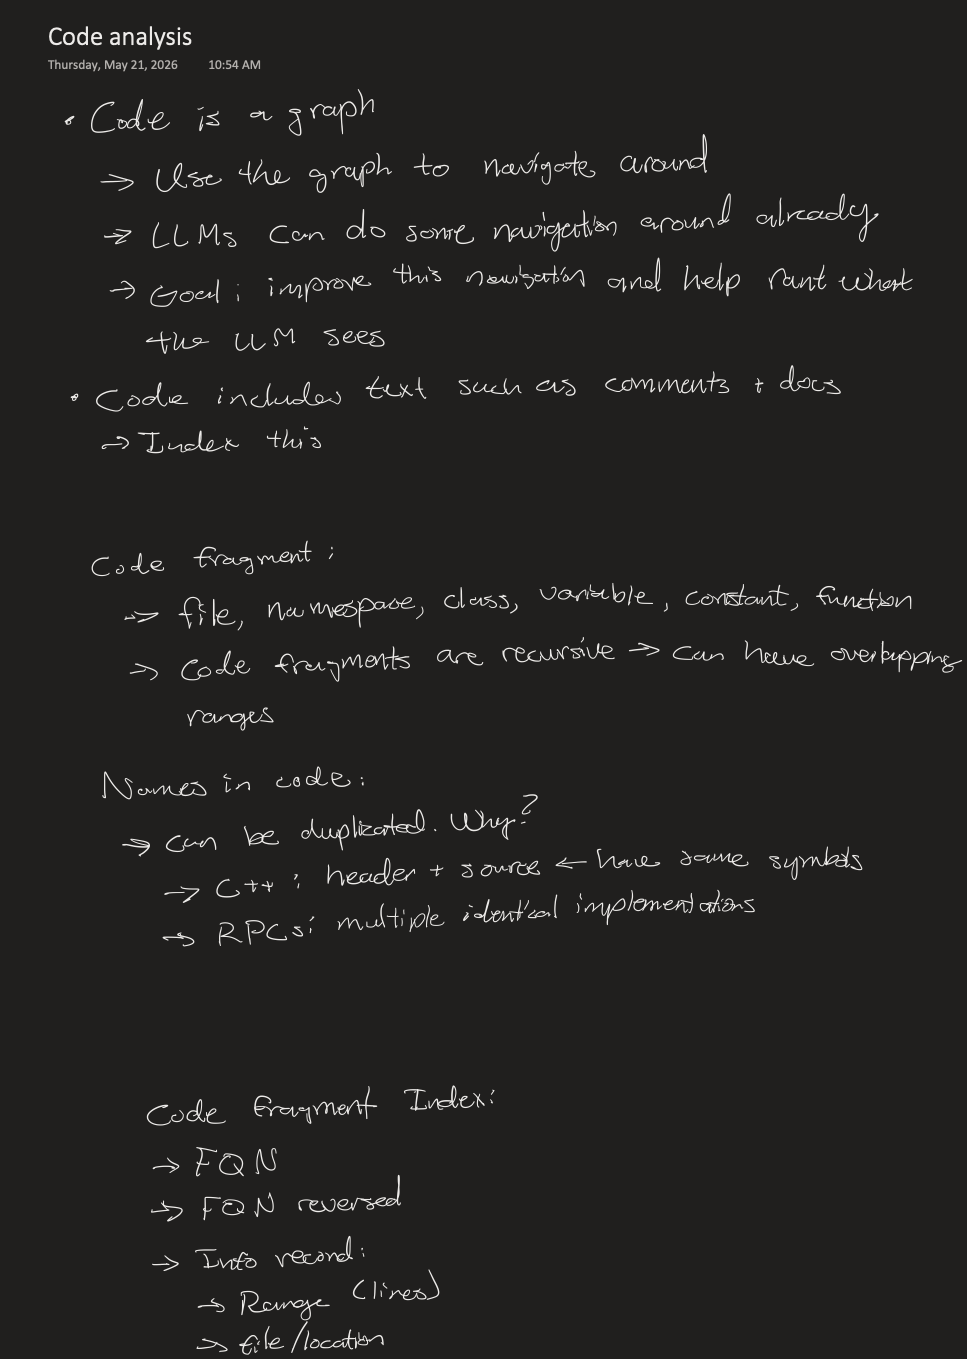

### Data Acquisition

Data Acquisition was one of the broken architecture pieces in v0. Let's fix it with better pluggable architecture:

```typescript
interface ICrawler {
    init(basepath: string): Promise<bool>;
    read(path: string): Promise<IFile>;
    onNewFile: ((file: IFile) => void);
    startCrawl: (isInitialCrawl: boolean) => void;
    stopCrawl: () => void;
    isCrawling: () => boolean;
    startWatch: () => void; // throw if not supported
    stopWatch: () => void; // throw if not supported
    getCrawlRemaining: () => ICrawlStat;
}

interface IFile {
    data: Blob;
    filepath: string;
    root?: number | null; // i16 or i32 ideally
    metadata?: Record<string, unknown> | undefined;
}

interface ICrawlStat {
    numCrawled: number;
    numRemaining: number;
}
```

### IR Generation

The job of the IR is to represent any arbitrary document in an indexable manner.

The inspiration for the IR in this project comes from A LOT of places and my own experience LOL
* [My experience developing Periscope](https://github.com/yash101/periscope/blob/main/src/main/indexer/Indexable.ts)
* [XML output from Doxygen](https://www.doxygen.nl/manual/output.html)
* [VEX IR (valgrind)](https://github.com/smparkes/valgrind-vex/blob/master/pub/libvex_ir.h)
* [Angr (Shellphish)](https://docs.angr.io/en/latest/index.html)
* Objdump format

Goals of the IR format:

* Store the content to be indexed in as clean and pure of a ways as possible
* Maintain mapping back to source
* Contain as much information as possible
* Have the ability to be extended dynamically

Why?

We have modular and pluggable indexers. Indexers can decide what to pull and use from each IR. Keeping the IR as extensive as possible opens us up to more indexer capabilities

### Extraction

The job of extractors is to take acquired data, from the data acqusition layer, and turn it into IR.

Current planned extractors:

* JavaScript/TypeScript: tsc + tsdoc (I'm not 100% sure if tsdoc is needed)
* Tree-sitter for its supported languages
* Doxygen for C/C++ and its supported languages
* Binaries: disasterisk (not yet built, but architecture is done)
    * Automatic binary analysis and dynamic relinking

### Indexers

We'll build a few indexers:

1. Sqlite3/FTS5. Why? Because it's lightweight, easy to work with, and is actually works well for full text search queries
2. `angels_deserve_to_die`: the LMDB-based indexers to specifically index the topology and complex relationships in code
3. `scorched_earth`: call ripgrep
4. OpenSearch
5. Embedding search with pgvector or FAISS

### Indexing Strategy: Sqlite3/FTS5

Mainly keep it the same, perhaps eagerly find more text sources to dump into it.

### Indexing Strategy: LMDB

Since this project is starting to become serious, might as well as come up with a name for this indexing strategy... `angels_deserve_to_die` (from Chop Suey)

